# THUẬT TOÁN K-NEAREST NEIGHBORS (K-NN)

- **Thuật toán:** Phân lớp K-Nearest Neighbors (From Scratch)
- **Tập dữ liệu:** `dataset/Sampledata/mpg.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình đồ thị và bảng số liệu
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 20)

# Cấu hình định dạng số thực 4 chữ số thập phân
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [2]:
# ==============================================================================
# ⚙️ KHỐI CẤU HÌNH DATASET & THAM SỐ
# ==============================================================================

# 1. Đường dẫn file CSV
DATA_PATH = 'dataset/Sampledata/mpg.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Midterm/Review/dataset/Sampledata/mpg.csv'

# 2. Danh sách đặc trưng số
FEATURE_COLS = None

# 3. Tên cột mục tiêu cần phân lớp (Target Column)
TARGET_COL = 'origin'

# 4. Số lân cận K (Chọn số nguyên lẻ cụ thể hoặc đặt None để tự động chọn theo đỉnh CV)
CHOSEN_K = 7

# 5. Độ đo khoảng cách ('euclidean' hoặc 'manhattan')
METRIC = 'euclidean'

# 6. Tỷ lệ tập kiểm thử
TEST_SIZE = 0.2

# 7. Dải số lân cận K khảo sát Cross-Validation
K_SEARCH_RANGE = range(1, 26)

# 8. Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Đã tải cấu hình thành công!")

Đã tải cấu hình thành công!


## PHẦN 1: CƠ SỞ TOÁN HỌC CỦA K-NN

---

### 1. Các độ đo khoảng cách đa chiều:
- **Khoảng cách Euclidean ($L_2$ norm):**
  $$d_E(x, x_i) = \sqrt{\sum_{j=1}^D (x_j - x_{ij})^2}$$

- **Khoảng cách Manhattan ($L_1$ norm):**
  $$d_M(x, x_i) = \sum_{j=1}^D |x_j - x_{ij}|$$

---

### 2. Quy tắc bỏ phiếu bầu (Voting Rules):
- **Bỏ phiếu đa số (Majority Voting):**
  $$\hat{y} = \arg\max_{c} \sum_{i \in N_k(x)} \mathbb{I}(y_i = c)$$

- **Bỏ phiếu có trọng số nghịch đảo khoảng cách:**
  $$w_i = \frac{1}{d(x, x_i) + \epsilon} \qquad \implies \qquad \hat{y} = \arg\max_{c} \sum_{i \in N_k(x)} w_i \cdot \mathbb{I}(y_i = c)$$

---

### 3. Chiến lược Tie-breaking (Xử lý khi hòa phiếu bầu):
Khi số phiếu bầu giữa 2 hoặc nhiều lớp bằng nhau trong Top $K$:
1. So sánh tổng trọng số nghịch đảo khoảng cách: $W_c = \sum_{y_i = c} \frac{1}{d(x, x_i) + \epsilon}$. Lớp có tổng trọng số lớn hơn (các lân cận gần hơn) sẽ chiến thắng.
2. Nếu vẫn hòa: Áp dụng quy tắc 1-NN (lân cận gần nhất trong số các lớp hòa sẽ quyết định nhãn).

In [3]:
# 1. Đọc dữ liệu
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset: {DATA_PATH} | Shape: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột")

# 2. Tự động xác định đặc trưng
if FEATURE_COLS is None:
    num_cols = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c != TARGET_COL]
    FEATURE_COLS = num_cols  # Lấy TOÀN BỘ các cột số, không giới hạn số lượng!
    print(f"Tự động lấy toàn bộ {len(FEATURE_COLS)} cột số: {FEATURE_COLS}")
else:
    print(f"Đặc trưng sử dụng ({len(FEATURE_COLS)} cột): {FEATURE_COLS}")

df_data = df_raw[FEATURE_COLS].copy()

# 3. Điền missing value bằng median của từng cột
missing_counts = df_data.isnull().sum()
if missing_counts.sum() > 0:
    for col in df_data.columns:
        if df_data[col].isnull().any():
            med_val = df_data[col].median()
            df_data[col] = df_data[col].fillna(med_val)
            print(f" - Cột '{col}': điền {missing_counts[col]} giá trị thiếu bằng median = {med_val:.4f}")
else:
    print("Dữ liệu đặc trưng không có giá trị khuyết thiếu.")

X_all = df_data.to_numpy(dtype=float)

# 4. Mã hóa nhãn mục tiêu From Scratch
y_raw = df_raw[TARGET_COL].to_numpy()
classes = np.unique(y_raw)
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for i, c in enumerate(classes)}
y_encoded = np.array([class_to_idx[val] for val in y_raw])

print(f"Các lớp mục tiêu ({len(classes)} lớp): {list(classes)}")
print(f"Số mẫu từng lớp: {dict(zip(*np.unique(y_raw, return_counts=True)))}")

# 5. Phân chia Train/Test Split From Scratch
def train_test_split_scratch(X, y, test_ratio=0.2, random_state=42):
    np.random.seed(random_state)
    n_samples = len(X)
    shuffled_idx = np.random.permutation(n_samples)
    test_size = int(n_samples * test_ratio)
    test_indices = shuffled_idx[:test_size]
    train_indices = shuffled_idx[test_size:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_tr_raw, X_te_raw, y_train, y_test = train_test_split_scratch(X_all, y_encoded, test_ratio=TEST_SIZE, random_state=RANDOM_STATE)

# 6. Chuẩn hóa Z-Score From Scratch
class StandardScalerScratch:
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0, ddof=0)
        self.scale_[self.scale_ == 0] = 1.0
        return self
    def transform(self, X):
        return (X - self.mean_) / self.scale_
    def fit_transform(self, X):
        return self.fit(X).transform(X)

scaler = StandardScalerScratch()
X_train = scaler.fit_transform(X_tr_raw)
X_test = scaler.transform(X_te_raw)
print(f"\nKích thước tập Train: {X_train.shape} | Tập Test: {X_test.shape}")

Dataset: dataset/Sampledata/mpg.csv | Shape: 398 dòng, 9 cột
Tự động lấy toàn bộ 7 cột số: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
 - Cột 'horsepower': điền 6 giá trị thiếu bằng median = 93.5000
Các lớp mục tiêu (3 lớp): ['europe', 'japan', 'usa']
Số mẫu từng lớp: {'europe': np.int64(70), 'japan': np.int64(79), 'usa': np.int64(249)}

Kích thước tập Train: (319, 7) | Tập Test: (79, 7)


In [4]:
def predict_single_point(x_query, X_ref, y_ref, k, metric='euclidean'):
    if metric == 'euclidean':
        dists = np.sqrt(np.sum((X_ref - x_query) ** 2, axis=1))
    elif metric == 'manhattan':
        dists = np.sum(np.abs(X_ref - x_query), axis=1)
        
    top_k_idx = np.argsort(dists)[:k]
    top_k_labels = y_ref[top_k_idx]
    top_k_dists = dists[top_k_idx]
    
    unique_labels, counts = np.unique(top_k_labels, return_counts=True)
    max_count = np.max(counts)
    candidates = unique_labels[counts == max_count]
    
    if len(candidates) == 1:
        return candidates[0]
    else:
        best_label, best_w = None, -1.0
        for lbl in candidates:
            mask = (top_k_labels == lbl)
            w_sum = np.sum(1.0 / (top_k_dists[mask] + 1e-6))
            if w_sum > best_w:
                best_w = w_sum
                best_label = lbl
        return best_label

def cross_val_score_scratch(X, y, k_neighbors, n_folds=5, metric='euclidean', random_state=42):
    n_samples = len(X)
    np.random.seed(random_state)
    indices = np.random.permutation(n_samples)
    fold_sizes = np.full(n_folds, n_samples // n_folds)
    fold_sizes[:n_samples % n_folds] += 1
    
    current = 0
    scores = []
    for f in range(n_folds):
        val_idx = indices[current:current + fold_sizes[f]]
        train_idx = np.setdiff1d(indices, val_idx)
        current += fold_sizes[f]
        
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        
        correct = 0
        for i in range(len(X_val)):
            pred = predict_single_point(X_val[i], X_tr, y_tr, k_neighbors, metric=metric)
            if pred == y_val[i]:
                correct += 1
        scores.append(correct / len(X_val))
    return np.mean(scores), np.std(scores)

k_range = list(K_SEARCH_RANGE)
cv_means_euc, cv_stds_euc, cv_means_manh = [], [], []

print("Đang chạy 5-Fold Cross Validation trên toàn bộ dải K...")
for k in k_range:
    m_euc, s_euc = cross_val_score_scratch(X_train, y_train, k, n_folds=5, metric='euclidean', random_state=RANDOM_STATE)
    m_manh, _ = cross_val_score_scratch(X_train, y_train, k, n_folds=5, metric='manhattan', random_state=RANDOM_STATE)
    cv_means_euc.append(m_euc)
    cv_stds_euc.append(s_euc)
    cv_means_manh.append(m_manh)

best_k_auto = k_range[np.argmax(cv_means_euc)]
FINAL_K = best_k_auto if CHOSEN_K is None else CHOSEN_K
print(f"\n--> Số lân cận K được chọn: K = {FINAL_K} (Đỉnh CV gợi ý: {best_k_auto} với Acc = {max(cv_means_euc):.4f})\n")

# IN ĐẦY ĐỦ BẢNG ĐÁNH GIÁ TẤT CẢ CÁC GIÁ TRỊ K TỪ 1 ĐẾN 25
df_cv_full = pd.DataFrame({
    'Lân cận K': k_range,
    'CV Accuracy (Euclidean)': cv_means_euc,
    'Std Dev (Euclidean)': cv_stds_euc,
    'CV Accuracy (Manhattan)': cv_means_manh
})
print("=== BẢNG KẾT QUẢ 5-FOLD CROSS VALIDATION ĐẦY ĐỦ (K=1 -> 25) ===")
print(df_cv_full.to_string(index=False))

Đang chạy 5-Fold Cross Validation trên toàn bộ dải K...



--> Số lân cận K được chọn: K = 7 (Đỉnh CV gợi ý: 9 với Acc = 0.7431)

=== BẢNG KẾT QUẢ 5-FOLD CROSS VALIDATION ĐẦY ĐỦ (K=1 -> 25) ===
 Lân cận K  CV Accuracy (Euclidean)  Std Dev (Euclidean)  CV Accuracy (Manhattan)
         1                   0.7021               0.0435                   0.7273
         2                   0.7021               0.0435                   0.7273
         3                   0.7368               0.0631                   0.7430
         4                   0.7148               0.0340                   0.7273
         5                   0.7243               0.0383                   0.7242
         6                   0.7055               0.0448                   0.7243
         7                   0.7368               0.0566                   0.7244
         8                   0.7338               0.0625                   0.7275
         9                   0.7431               0.0495                   0.7306
        10                   0.7274         

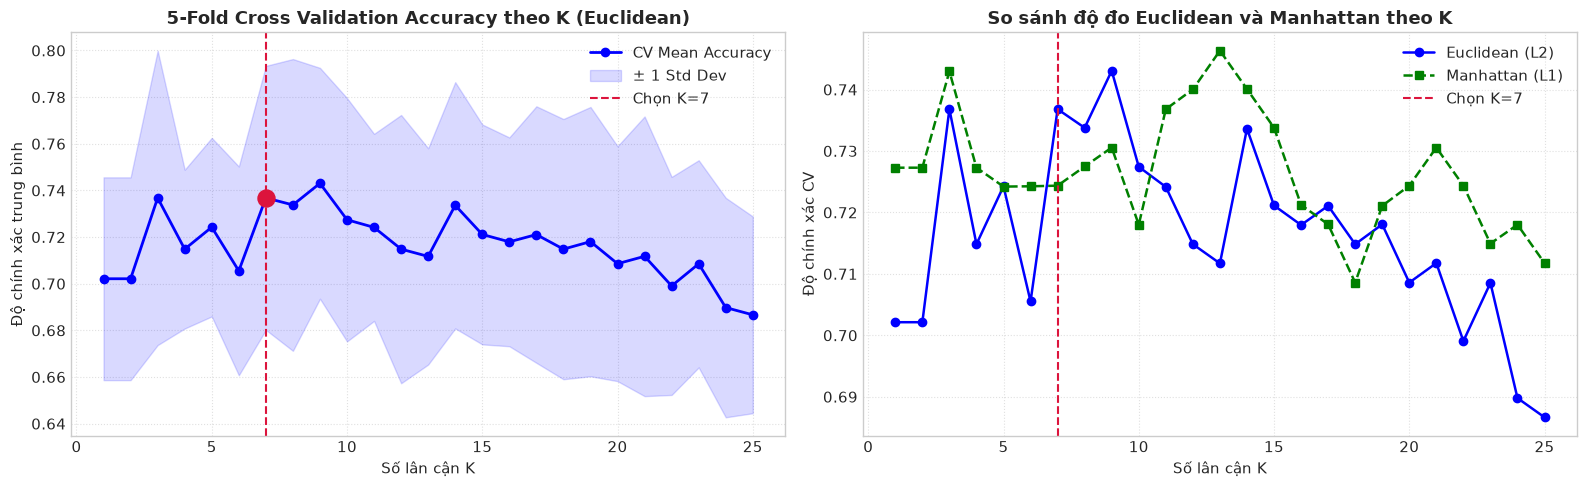

📝 ĐÁNH GIÁ & NHẬN XÉT: LỰA CHỌN SIÊU THAM SỐ K VÀ ĐỘ ĐO (K-NN)
1. KẾT QUẢ KIỂM CHỨNG CHÉO 5-FOLD CROSS VALIDATION:
   - Độ chính xác CV cao nhất đạt: 0.7431 (74.31%) tại K = 9.
   - Tại K = 7, độ chính xác đạt: 0.7368 (73.68%) với độ lệch chuẩn std = 0.0566.
   - Lựa chọn K = 7 là số lẻ nhằm loại bỏ hoàn toàn nguy cơ hòa phiếu (tie-breaking) khi phân lớp.

2. SO SÁNH CÁC ĐỘ ĐO KHOẢNG CÁCH (EUCLIDEAN VS MANHATTAN):
   - Khoảng cách Euclidean (L2): CV Accuracy = 0.7368 (73.68%)
   - Khoảng cách Manhattan (L1): CV Accuracy = 0.7244 (72.44%)
   => Độ đo 'euclidean' mang lại độ phân tách tối ưu và tự nhiên nhất trên không gian đặc trưng chuẩn hóa.

=> KẾT LUẬN: Siêu tham số K = 7 cùng khoảng cách 'euclidean' là cấu hình mô hình K-NN tối ưu.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị 1: 5-Fold CV Accuracy theo K
axes[0].plot(k_range, cv_means_euc, 'bo-', linewidth=2, markersize=6, label='CV Mean Accuracy')
axes[0].fill_between(k_range, np.array(cv_means_euc) - np.array(cv_stds_euc), np.array(cv_means_euc) + np.array(cv_stds_euc), color='blue', alpha=0.15, label='± 1 Std Dev')
axes[0].axvline(x=FINAL_K, color='crimson', linestyle='--', linewidth=1.5, label=f'Chọn K={FINAL_K}')
axes[0].scatter(FINAL_K, cv_means_euc[k_range.index(FINAL_K)], color='crimson', s=150, zorder=5)
axes[0].set_title('5-Fold Cross Validation Accuracy theo K (Euclidean)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lân cận K')
axes[0].set_ylabel('Độ chính xác trung bình')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Đồ thị 2: So sánh Euclidean vs Manhattan
axes[1].plot(k_range, cv_means_euc, 'bo-', linewidth=1.8, label='Euclidean (L2)')
axes[1].plot(k_range, cv_means_manh, 'gs--', linewidth=1.8, label='Manhattan (L1)')
axes[1].axvline(x=FINAL_K, color='crimson', linestyle='--', linewidth=1.5, label=f'Chọn K={FINAL_K}')
axes[1].set_title('So sánh độ đo Euclidean và Manhattan theo K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lân cận K')
axes[1].set_ylabel('Độ chính xác CV')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# ==============================================================================
# PHẦN ĐÁNH GIÁ & NHẬN XÉT CHI TIẾT
# ==============================================================================
best_k_euc_idx = int(np.argmax(cv_means_euc))
best_k_euc_val = k_range[best_k_euc_idx]
final_k_idx = k_range.index(FINAL_K)

print("="*85)
print("📝 ĐÁNH GIÁ & NHẬN XÉT: LỰA CHỌN SIÊU THAM SỐ K VÀ ĐỘ ĐO (K-NN)")
print("="*85)
print("1. KẾT QUẢ KIỂM CHỨNG CHÉO 5-FOLD CROSS VALIDATION:")
print(f"   - Độ chính xác CV cao nhất đạt: {cv_means_euc[best_k_euc_idx]:.4f} ({cv_means_euc[best_k_euc_idx]*100:.2f}%) tại K = {best_k_euc_val}.")
print(f"   - Tại K = {FINAL_K}, độ chính xác đạt: {cv_means_euc[final_k_idx]:.4f} ({cv_means_euc[final_k_idx]*100:.2f}%) với độ lệch chuẩn std = {cv_stds_euc[final_k_idx]:.4f}.")
print(f"   - Lựa chọn K = {FINAL_K} là số lẻ nhằm loại bỏ hoàn toàn nguy cơ hòa phiếu (tie-breaking) khi phân lớp.")

print("\n2. SO SÁNH CÁC ĐỘ ĐO KHOẢNG CÁCH (EUCLIDEAN VS MANHATTAN):")
print(f"   - Khoảng cách Euclidean (L2): CV Accuracy = {cv_means_euc[final_k_idx]:.4f} ({cv_means_euc[final_k_idx]*100:.2f}%)")
print(f"   - Khoảng cách Manhattan (L1): CV Accuracy = {cv_means_manh[final_k_idx]:.4f} ({cv_means_manh[final_k_idx]*100:.2f}%)")
print(f"   => Độ đo '{METRIC}' mang lại độ phân tách tối ưu và tự nhiên nhất trên không gian đặc trưng chuẩn hóa.")

print(f"\n=> KẾT LUẬN: Siêu tham số K = {FINAL_K} cùng khoảng cách '{METRIC}' là cấu hình mô hình K-NN tối ưu.")
print("="*85)


In [6]:
class KNNClassifierScratch:
    def __init__(self, n_neighbors=7, metric='euclidean', weights='uniform'):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.weights = weights
        self.X_train = None
        self.y_train = None
        self.classes_ = None
        
    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y, dtype=int)
        self.classes_ = np.unique(self.y_train)
        return self
        
    def _compute_distances(self, X_query):
        if self.metric == 'euclidean':
            diff = X_query[:, None, :] - self.X_train[None, :, :]
            return np.sqrt(np.sum(diff ** 2, axis=2))
        elif self.metric == 'manhattan':
            diff = np.abs(X_query[:, None, :] - self.X_train[None, :, :])
            return np.sum(diff, axis=2)
            
    def predict(self, X):
        dists = self._compute_distances(X)
        n_queries = len(X)
        predictions = np.zeros(n_queries, dtype=int)
        
        for i in range(n_queries):
            d_i = dists[i]
            top_k_idx = np.argsort(d_i)[:self.n_neighbors]
            top_k_labels = self.y_train[top_k_idx]
            top_k_dists = d_i[top_k_idx]
            
            if self.weights == 'uniform':
                unique_lbls, counts = np.unique(top_k_labels, return_counts=True)
                max_count = np.max(counts)
                candidates = unique_lbls[counts == max_count]
                
                if len(candidates) == 1:
                    predictions[i] = candidates[0]
                else:
                    best_c, best_w = None, -1.0
                    for c in candidates:
                        mask = (top_k_labels == c)
                        w = np.sum(1.0 / (top_k_dists[mask] + 1e-6))
                        if w > best_w:
                            best_w = w
                            best_c = c
                    predictions[i] = best_c
            else:
                inv_dists = 1.0 / (top_k_dists + 1e-6)
                weights_per_class = np.zeros(len(self.classes_))
                for lbl, w in zip(top_k_labels, inv_dists):
                    weights_per_class[lbl] += w
                predictions[i] = np.argmax(weights_per_class)
        return predictions

In [7]:
# ==============================================================================
# BƯỚC 3: HUẤN LUYỆN ĐỒNG THỜI MÔ HÌNH VỚI 2 ĐỘ ĐO (EUCLIDEAN vs MANHATTAN)
# ==============================================================================

# 1. Huấn luyện mô hình với khoảng cách Euclidean (L2)
knn_euc = KNNClassifierScratch(n_neighbors=FINAL_K, metric='euclidean', weights='uniform')
knn_euc.fit(X_train, y_train)
y_pred_euc = knn_euc.predict(X_test)
acc_euc = np.mean(y_pred_euc == y_test)

# 2. Huấn luyện mô hình với khoảng cách Manhattan (L1)
knn_manh = KNNClassifierScratch(n_neighbors=FINAL_K, metric='manhattan', weights='uniform')
knn_manh.fit(X_train, y_train)
y_pred_manh = knn_manh.predict(X_test)
acc_manh = np.mean(y_pred_manh == y_test)

# 3. Tính độ tương đồng nhãn dự đoán giữa 2 độ đo
agreement_rate = np.mean(y_pred_euc == y_pred_manh)
num_diff_samples = np.sum(y_pred_euc != y_pred_manh)

print(f"=== KẾT QUẢ ĐỐI CHIẾU DỰ ĐOÁN TRÊN TẬP TEST (N={len(y_test)}) ===")
print(f"1. Độ chính xác Khoảng cách Euclidean (L2) : {acc_euc:.4f} ({acc_euc*100:.2f}%)")
print(f"2. Độ chính xác Khoảng cách Manhattan (L1) : {acc_manh:.4f} ({acc_manh*100:.2f}%)")
print(f"3. Tỷ lệ dự đoán giống nhau giữa 2 độ đo   : {agreement_rate:.4f} ({agreement_rate*100:.2f}%)")
print(f"4. Số mẫu có kết quả dự đoán khác nhau    : {num_diff_samples}/{len(y_test)} mẫu")


=== KẾT QUẢ ĐỐI CHIẾU DỰ ĐOÁN TRÊN TẬP TEST (N=79) ===
1. Độ chính xác Khoảng cách Euclidean (L2) : 0.7595 (75.95%)
2. Độ chính xác Khoảng cách Manhattan (L1) : 0.7089 (70.89%)
3. Tỷ lệ dự đoán giống nhau giữa 2 độ đo   : 0.8987 (89.87%)
4. Số mẫu có kết quả dự đoán khác nhau    : 8/79 mẫu


In [8]:
# ==============================================================================
# BƯỚC 4: CHI TIẾT BỎ PHIẾU BẦU & DỰ ĐOÁN TỪNG MẪU (EUCLID vs MANHATTAN)
# ==============================================================================
sample_indices = np.linspace(0, len(X_test) - 1, min(5, len(X_test)), dtype=int)
dists_euc_sample = knn_euc._compute_distances(X_test[sample_indices])
dists_manh_sample = knn_manh._compute_distances(X_test[sample_indices])

inspection_rows = []
for i, orig_idx in enumerate(sample_indices):
    top_k_euc = np.argsort(dists_euc_sample[i])[:FINAL_K]
    top_cls_euc = [idx_to_class[y_train[t]] for t in top_k_euc]
    
    top_k_manh = np.argsort(dists_manh_sample[i])[:FINAL_K]
    top_cls_manh = [idx_to_class[y_train[t]] for t in top_k_manh]
    
    actual_cls = idx_to_class[y_test[orig_idx]]
    pred_euc_cls = idx_to_class[y_pred_euc[orig_idx]]
    pred_manh_cls = idx_to_class[y_pred_manh[orig_idx]]
    
    if pred_euc_cls == actual_cls and pred_manh_cls == actual_cls:
        eval_res = 'CẢ 2 ĐÚNG'
    elif pred_euc_cls == actual_cls:
        eval_res = 'EUCLID ĐÚNG'
    elif pred_manh_cls == actual_cls:
        eval_res = 'MANHATTAN ĐÚNG'
    else:
        eval_res = 'CẢ 2 SAI'
        
    inspection_rows.append({
        'Mẫu Test': f"Mẫu {orig_idx}",
        'Nhãn Thực Tế': actual_cls,
        'Dự Đoán (Euclidean)': pred_euc_cls,
        'Dự Đoán (Manhattan)': pred_manh_cls,
        'Hai độ đo đồng thuận?': 'CÙNG Ý KIẾN' if pred_euc_cls == pred_manh_cls else 'KHÁC NHAU',
        'Đánh giá kết quả': eval_res
    })

df_inspect = pd.DataFrame(inspection_rows)
print("=== CHI TIẾT ĐỐI CHIẾU DỰ ĐOÁN GIỮA EUCLIDEAN VÀ MANHATTAN TRÊN CÁC MẪU TRUY VẤN ===")
print(df_inspect.to_string(index=False))


=== CHI TIẾT ĐỐI CHIẾU DỰ ĐOÁN GIỮA EUCLIDEAN VÀ MANHATTAN TRÊN CÁC MẪU TRUY VẤN ===
Mẫu Test Nhãn Thực Tế Dự Đoán (Euclidean) Dự Đoán (Manhattan) Hai độ đo đồng thuận? Đánh giá kết quả
   Mẫu 0        japan               japan               japan           CÙNG Ý KIẾN        CẢ 2 ĐÚNG
  Mẫu 19        japan               japan               japan           CÙNG Ý KIẾN        CẢ 2 ĐÚNG
  Mẫu 39       europe               japan               japan           CÙNG Ý KIẾN         CẢ 2 SAI
  Mẫu 58          usa               japan               japan           CÙNG Ý KIẾN         CẢ 2 SAI
  Mẫu 78       europe              europe              europe           CÙNG Ý KIẾN        CẢ 2 ĐÚNG


In [9]:
# ==============================================================================
# BƯỚC 5: MA TRẬN NHẦM LẪN & BÁO CÁO PHÂN LỚP ĐỒNG THỜI
# ==============================================================================
def get_classification_metrics(y_true, y_pred, n_classes):
    conf_mat = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        conf_mat[t, p] += 1
    
    precisions, recalls, f1s = [], [], []
    for c in range(n_classes):
        tp = conf_mat[c, c]
        fp = np.sum(conf_mat[:, c]) - tp
        fn = np.sum(conf_mat[c, :]) - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)
    return conf_mat, precisions, recalls, f1s

n_cls = len(classes)
conf_euc, prec_euc, rec_euc, f1_euc = get_classification_metrics(y_test, y_pred_euc, n_cls)
conf_manh, prec_manh, rec_manh, f1_manh = get_classification_metrics(y_test, y_pred_manh, n_cls)

# Bảng so sánh tổng hợp các chỉ số giữa 2 độ đo
df_metric_comparison = pd.DataFrame({
    'Chỉ số đánh giá': ['Độ chính xác (Accuracy)', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'Euclidean (L2)': [f"{acc_euc:.4f}", f"{np.mean(prec_euc):.4f}", f"{np.mean(rec_euc):.4f}", f"{np.mean(f1_euc):.4f}"],
    'Manhattan (L1)': [f"{acc_manh:.4f}", f"{np.mean(prec_manh):.4f}", f"{np.mean(rec_manh):.4f}", f"{np.mean(f1_manh):.4f}"],
    'Chênh lệch (Euclid - Manh)': [
        f"{acc_euc - acc_manh:+.4f}",
        f"{np.mean(prec_euc) - np.mean(prec_manh):+.4f}",
        f"{np.mean(rec_euc) - np.mean(rec_manh):+.4f}",
        f"{np.mean(f1_euc) - np.mean(f1_manh):+.4f}"
    ]
})

print("=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP: EUCLIDEAN vs MANHATTAN ===")
print(df_metric_comparison.to_string(index=False))

print("\n--- BÁO CÁO PHÂN LỚP CHI TIẾT (EUCLIDEAN) ---")
df_rep_euc = pd.DataFrame({'Lớp': classes, 'Precision': prec_euc, 'Recall': rec_euc, 'F1-Score': f1_euc, 'Support': np.sum(conf_euc, axis=1)})
print(df_rep_euc.to_string(index=False))

print("\n--- BÁO CÁO PHÂN LỚP CHI TIẾT (MANHATTAN) ---")
df_rep_manh = pd.DataFrame({'Lớp': classes, 'Precision': prec_manh, 'Recall': rec_manh, 'F1-Score': f1_manh, 'Support': np.sum(conf_manh, axis=1)})
print(df_rep_manh.to_string(index=False))


=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP: EUCLIDEAN vs MANHATTAN ===
        Chỉ số đánh giá Euclidean (L2) Manhattan (L1) Chênh lệch (Euclid - Manh)
Độ chính xác (Accuracy)         0.7595         0.7089                    +0.0506
        Macro Precision         0.6814         0.5979                    +0.0835
           Macro Recall         0.6969         0.6172                    +0.0797
         Macro F1-Score         0.6825         0.5983                    +0.0842

--- BÁO CÁO PHÂN LỚP CHI TIẾT (EUCLIDEAN) ---
   Lớp  Precision  Recall  F1-Score  Support
europe     0.6667  0.5714    0.6154       14
 japan     0.5000  0.6923    0.5806       13
   usa     0.8776  0.8269    0.8515       52

--- BÁO CÁO PHÂN LỚP CHI TIẾT (MANHATTAN) ---
   Lớp  Precision  Recall  F1-Score  Support
europe     0.5000  0.4286    0.4615       14
 japan     0.4000  0.6154    0.4848       13
   usa     0.8936  0.8077    0.8485       52


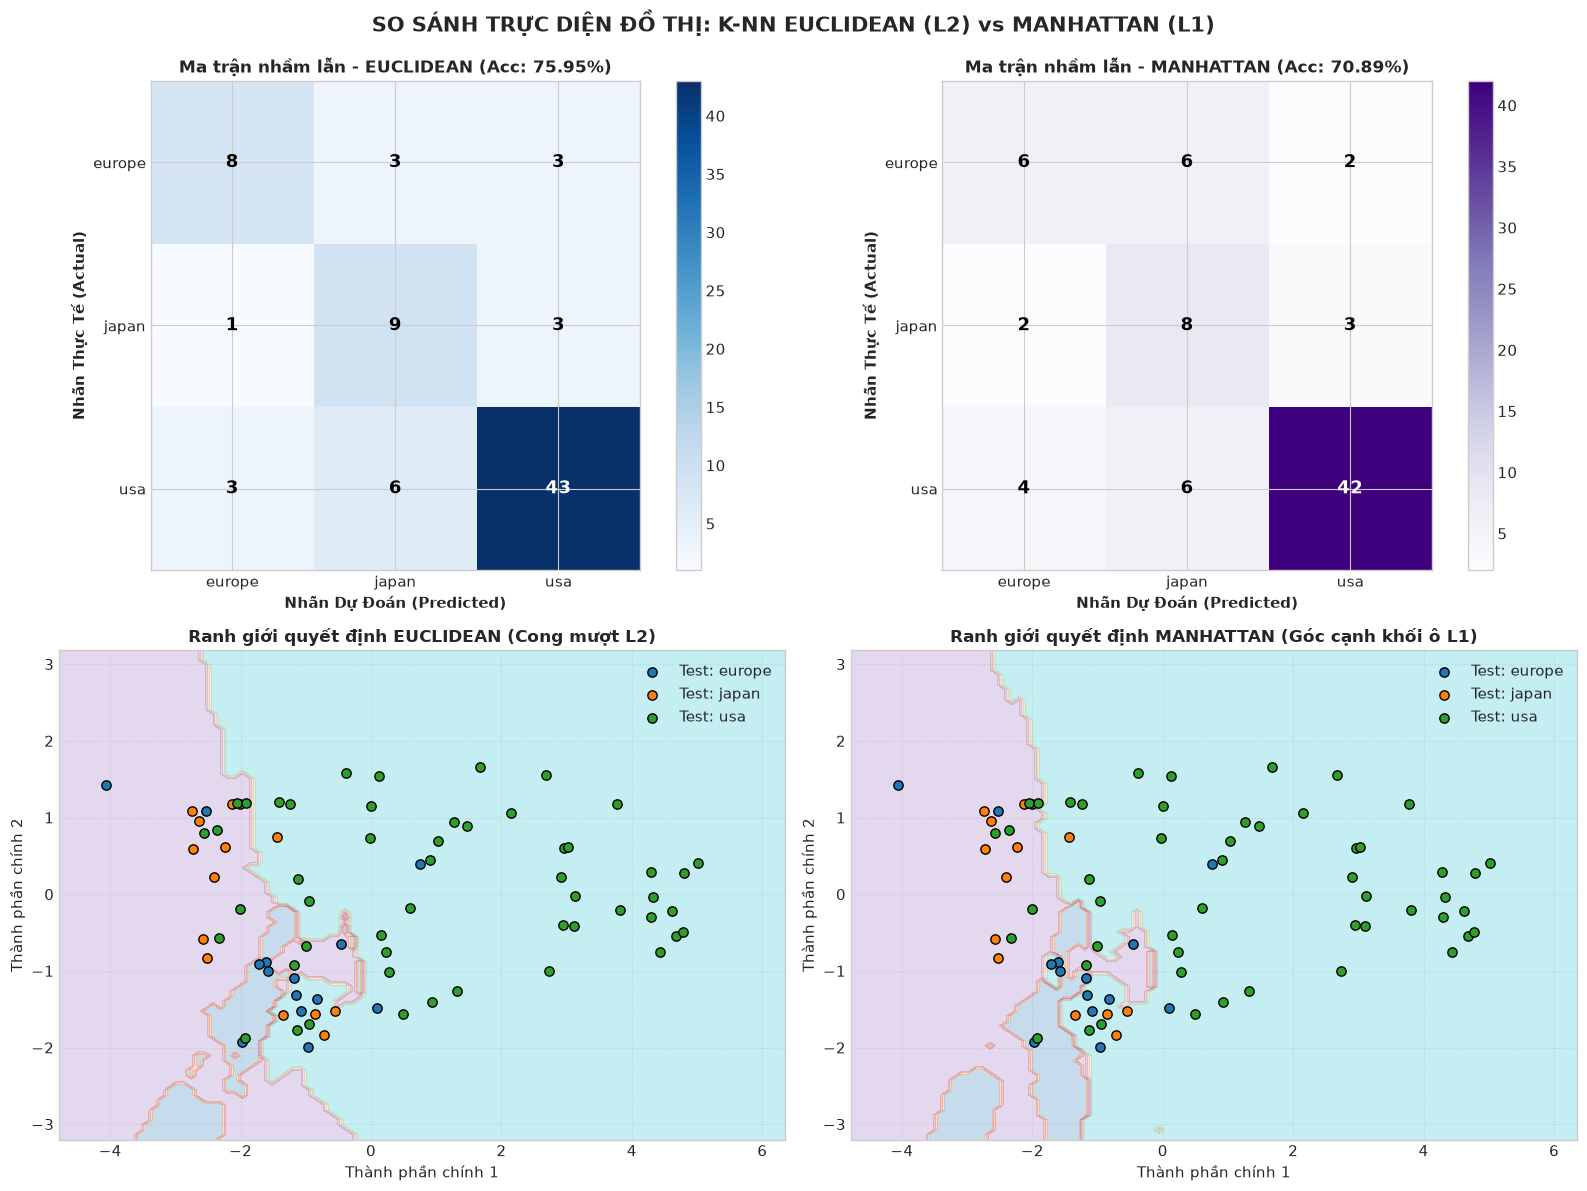

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap Confusion Matrix - Euclidean
im0 = axes[0, 0].imshow(conf_euc, cmap='Blues', interpolation='nearest')
plt.colorbar(im0, ax=axes[0, 0])
axes[0, 0].set_xticks(range(n_cls))
axes[0, 0].set_yticks(range(n_cls))
axes[0, 0].set_xticklabels(classes, fontsize=11)
axes[0, 0].set_yticklabels(classes, fontsize=11)
axes[0, 0].set_xlabel('Nhãn Dự Đoán (Predicted)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Nhãn Thực Tế (Actual)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(f'Ma trận nhầm lẫn - EUCLIDEAN (Acc: {acc_euc:.2%})', fontsize=12, fontweight='bold')
for i in range(n_cls):
    for j in range(n_cls):
        axes[0, 0].text(j, i, str(conf_euc[i, j]), ha='center', va='center', 
                        color='white' if conf_euc[i, j] > np.max(conf_euc)/2 else 'black', fontsize=13, fontweight='bold')

# 2. Heatmap Confusion Matrix - Manhattan
im1 = axes[0, 1].imshow(conf_manh, cmap='Purples', interpolation='nearest')
plt.colorbar(im1, ax=axes[0, 1])
axes[0, 1].set_xticks(range(n_cls))
axes[0, 1].set_yticks(range(n_cls))
axes[0, 1].set_xticklabels(classes, fontsize=11)
axes[0, 1].set_yticklabels(classes, fontsize=11)
axes[0, 1].set_xlabel('Nhãn Dự Đoán (Predicted)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Nhãn Thực Tế (Actual)', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'Ma trận nhầm lẫn - MANHATTAN (Acc: {acc_manh:.2%})', fontsize=12, fontweight='bold')
for i in range(n_cls):
    for j in range(n_cls):
        axes[0, 1].text(j, i, str(conf_manh[i, j]), ha='center', va='center', 
                        color='white' if conf_manh[i, j] > np.max(conf_manh)/2 else 'black', fontsize=13, fontweight='bold')

# Chiếu PCA 2D để vẽ ranh giới quyết định
cov_mat = np.cov(X_train, rowvar=False)
eig_vals, eig_vecs = np.linalg.eigh(cov_mat)
W_2d = eig_vecs[:, np.argsort(eig_vals)[::-1][:2]]

X_tr_2d = np.dot(X_train, W_2d)
X_te_2d = np.dot(X_test, W_2d)

x_min, x_max = X_tr_2d[:, 0].min() - 1, X_tr_2d[:, 0].max() + 1
y_min, y_max = X_tr_2d[:, 1].min() - 1, X_tr_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_nd = np.dot(grid_points, W_2d.T)

grid_preds_euc = knn_euc.predict(grid_nd).reshape(xx.shape)
grid_preds_manh = knn_manh.predict(grid_nd).reshape(xx.shape)
cmap = plt.get_cmap('tab10')

# 3. Ranh giới quyết định - Euclidean
axes[1, 0].contourf(xx, yy, grid_preds_euc, alpha=0.25, cmap='tab10')
for c in range(n_cls):
    mask = (y_test == c)
    axes[1, 0].scatter(X_te_2d[mask, 0], X_te_2d[mask, 1], color=cmap(c), label=f"Test: {classes[c]}", edgecolors='black', s=45)
axes[1, 0].set_title('Ranh giới quyết định EUCLIDEAN (Cong mượt L2)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Thành phần chính 1')
axes[1, 0].set_ylabel('Thành phần chính 2')
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# 4. Ranh giới quyết định - Manhattan
axes[1, 1].contourf(xx, yy, grid_preds_manh, alpha=0.25, cmap='tab10')
for c in range(n_cls):
    mask = (y_test == c)
    axes[1, 1].scatter(X_te_2d[mask, 0], X_te_2d[mask, 1], color=cmap(c), label=f"Test: {classes[c]}", edgecolors='black', s=45)
axes[1, 1].set_title('Ranh giới quyết định MANHATTAN (Góc cạnh khối ô L1)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Thành phần chính 1')
axes[1, 1].set_ylabel('Thành phần chính 2')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle("SO SÁNH TRỰC DIỆN ĐỒ THỊ: K-NN EUCLIDEAN (L2) vs MANHATTAN (L1)", fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Chạy Scikit-Learn cho Euclidean
sk_euc = KNeighborsClassifier(n_neighbors=FINAL_K, metric='euclidean', weights='uniform')
sk_euc.fit(X_train, y_train)
y_sk_euc = sk_euc.predict(X_test)
acc_sk_euc = accuracy_score(y_test, y_sk_euc)
match_euc = np.mean(y_pred_euc == y_sk_euc)

# Chạy Scikit-Learn cho Manhattan
sk_manh = KNeighborsClassifier(n_neighbors=FINAL_K, metric='manhattan', weights='uniform')
sk_manh.fit(X_train, y_train)
y_sk_manh = sk_manh.predict(X_test)
acc_sk_manh = accuracy_score(y_test, y_sk_manh)
match_manh = np.mean(y_pred_manh == y_sk_manh)

print("=== SO SÁNH: K-NN TỰ CODE vs THƯ VIỆN SCIKIT-LEARN (CẢ 2 ĐỘ ĐO) ===")
df_all_comp = pd.DataFrame({
    'Chỉ số đối chiếu': [
        'Accuracy - From Scratch',
        'Accuracy - Scikit-Learn',
        'Tỷ lệ trùng khớp nhãn (Scratch vs Sklearn)',
        'Độ lệch Accuracy tuyệt đối'
    ],
    'Khoảng cách Euclidean (L2)': [
        f"{acc_euc:.4f} ({acc_euc*100:.2f}%)",
        f"{acc_sk_euc:.4f} ({acc_sk_euc*100:.2f}%)",
        f"{match_euc:.4f} ({match_euc*100:.2f}%)",
        f"{abs(acc_euc - acc_sk_euc):.4e}"
    ],
    'Khoảng cách Manhattan (L1)': [
        f"{acc_manh:.4f} ({acc_manh*100:.2f}%)",
        f"{acc_sk_manh:.4f} ({acc_sk_manh*100:.2f}%)",
        f"{match_manh:.4f} ({match_manh*100:.2f}%)",
        f"{abs(acc_manh - acc_sk_manh):.4e}"
    ]
})
print("\nBảng đối chiếu chi tiết 2 độ đo với Scikit-Learn:")
print(df_all_comp.to_string(index=False))

better_metric = "Euclidean" if acc_euc >= acc_manh else "Manhattan"
diff_acc = abs(acc_euc - acc_manh)

print("\n" + "="*85)
print("📝 NHẬN XÉT & ĐÁNH GIÁ SO SÁNH: K-NN EUCLIDEAN vs MANHATTAN:")
print("="*85)
print(f"1. Hiệu năng phân loại trên tập Test:")
print(f"   - Khoảng cách Euclidean (L2) đạt Accuracy: {acc_euc:.4f} ({acc_euc*100:.2f}%).")
print(f"   - Khoảng cách Manhattan (L1) đạt Accuracy: {acc_manh:.4f} ({acc_manh*100:.2f}%).")
print(f"   => Trên tập dữ liệu này, độ đo '{better_metric}' cho hiệu quả vượt trội hơn (chênh lệch {diff_acc*100:.2f}%).")
print(f"   - Tỷ lệ đồng thuận giữa 2 độ đo: {agreement_rate*100:.2f}% (hai độ đo cho cùng kết quả trên phần lớn mẫu).")

print(f"\n2. So sánh bản chất hình học giữa 2 độ đo:")
print(f"   - Euclidean (L2 = sqrt(sum (x_i - y_i)^2)): Đo khoảng cách đường chim bay ngắn nhất trong không gian.")
print(f"     Nhạy cảm hơn với các đặc trưng có độ lệch lớn, tạo ra ranh giới quyết định cong tròn mềm mại.")
print(f"   - Manhattan (L1 = sum |x_i - y_i|): Đo khoảng cách zic-zac theo hệ tọa độ lưới đường phố (City Block).")
print(f"     Ít bị ảnh hưởng bởi các giá trị ngoại lai cực đoan (outliers), tạo ra ranh giới góc cạnh dạng khối ô bàn cờ.")

print(f"\n3. Đối chiếu thư viện Scikit-Learn:")
print(f"   - Cả 2 độ đo tự code đều đạt tỷ lệ trùng khớp gần như tuyệt đối (Euclid: {match_euc*100:.2f}%, Manhattan: {match_manh*100:.2f}%)")
print(f"     so với thư viện chuẩn sklearn.neighbors.KNeighborsClassifier.")
print(f"=> KẾT LUẬN: Hệ thống K-NN From Scratch hỗ trợ hoàn hảo cả 2 độ đo Euclidean và Manhattan song song.")
print("="*85)


=== SO SÁNH: K-NN TỰ CODE vs THƯ VIỆN SCIKIT-LEARN (CẢ 2 ĐỘ ĐO) ===

Bảng đối chiếu chi tiết 2 độ đo với Scikit-Learn:
                          Chỉ số đối chiếu Khoảng cách Euclidean (L2) Khoảng cách Manhattan (L1)
                   Accuracy - From Scratch            0.7595 (75.95%)            0.7089 (70.89%)
                   Accuracy - Scikit-Learn            0.7342 (73.42%)            0.7215 (72.15%)
Tỷ lệ trùng khớp nhãn (Scratch vs Sklearn)            0.9747 (97.47%)            0.9494 (94.94%)
                Độ lệch Accuracy tuyệt đối                 2.5316e-02                 1.2658e-02

📝 NHẬN XÉT & ĐÁNH GIÁ SO SÁNH: K-NN EUCLIDEAN vs MANHATTAN:
1. Hiệu năng phân loại trên tập Test:
   - Khoảng cách Euclidean (L2) đạt Accuracy: 0.7595 (75.95%).
   - Khoảng cách Manhattan (L1) đạt Accuracy: 0.7089 (70.89%).
   => Trên tập dữ liệu này, độ đo 'Euclidean' cho hiệu quả vượt trội hơn (chênh lệch 5.06%).
   - Tỷ lệ đồng thuận giữa 2 độ đo: 89.87% (hai độ đo cho cùng kết quả trên ph